In [3]:
import numpy as np
import math
from scipy.optimize import minimize
from scipy import ndimage


In [2]:
def prelec_weight(p, alpha):
    return np.exp(-((-np.log(p)) ** alpha))

def cpt_value(q, alpha, beta, lam, x0=0):
    diff = q - x0
    if diff >= 0:
        return diff ** alpha
    return -lam * ((-diff) ** beta)

def cpt_subjective_value(p, q_pref, q_no, prelec_alpha, value_alpha, value_beta, lam):
    w = prelec_weight(p, prelec_alpha)
    u_pref = cpt_value(q_pref, value_alpha, value_beta, lam)
    u_no = cpt_value(q_no, value_alpha, value_beta, lam)
    
    return w * (u_pref - u_no)

In [3]:
#### Logistic choice probability
def logistic(x):
    return 1 / (1 + np.exp(-x))

#### Negative log-likelihood
def neg_log_likelihood(params, p, q_pref, q_no, C):
    prelec_alpha, alpha, beta, lam, theta = params
    
    V = np.array([
        cpt_subjective_value(
            p[i], 
            q_pref[i], 
            q_no[i],
            prelec_alpha, 
            alpha, 
            beta, 
            lam
        ) for i in range(len(p))
    ])
    
    probs = logistic(theta * V)
    eps = 1e-9
    ll = np.sum(C * np.log(probs + eps) + (1 - C) * np.log(1 - probs + eps))
    return -ll  # minimize negative log lik

In [9]:
from importnb import Notebook
with Notebook():
    from LabSimpleEnv_2 import simulate_viewport_with_tiles, CPTPrefetchEnvSimple
    from LabSimpleEnv_2 import zipf

window_len = 10
n_users = 30
total_videos = 100
capacity = 50
step_size = 1.5
n_frames = 1_800
n = 4
num_tiles = n*n

yaw, pitch, tiles_per_frame, tiles_array = simulate_viewport_with_tiles(
    num_steps=n_frames,
    n=n,
    fov_yaw=120,
    fov_pitch=60,
    damping=0.99,
    step_size=step_size,
    start_yaw=180,
    start_pitch=0
)

user_tiles = [
    {
        "tiles": tiles_per_frame[start:(start + window_len)],
        "yaw": yaw[start:(start + window_len)],
        "pitch": pitch[start:(start + window_len)],
    } for start in range(0, n_users * window_len, window_len)
]

videos_requests_idx = zipf(n_users, total_videos=total_videos, alpha=1.0)

env = CPTPrefetchEnvSimple(
    num_tiles=num_tiles,
    n_users=n_users,
    cache_capacity=capacity,
    user_tiles=user_tiles,
    videos_requests=videos_requests_idx
)

obs = env.reset()
max_steps = window_len

p_data, q_pref, q_no, C_data = [], [], [], []

In [10]:
def requestTiles(step, i) -> np.ndarray:
    tile_request = np.zeros(num_tiles, dtype=int)
    
    for tile in user_tiles[i]['tiles'][step]:
        tx, ty = tile[0] - 1, tile[1] - 1
        tile_request[tx * n + ty] = 1
    return tile_request

def estimate_probabilities(videos_requests_idx, step, n_users):
    videos_frames = [
        {
            'user': i,
            'video': videos_requests_idx[i],
            'tiles': requestTiles(step, i)
        } for i in range(n_users)
    ]

    by_video = {}
    for user_action in videos_frames:
        vid = user_action.get('video', None)
        tiles = user_action.get('tiles', None)

        if vid not in by_video:
            by_video[vid] = np.zeros(num_tiles, dtype=int)
        
        by_video[vid] += (tiles > 0)

    video_tile_counts = []
    for vid, arr in by_video.items():
        for tile_idx, count in enumerate(arr):
            video_tile_counts.append((vid, tile_idx, count))

    # Sort by count descending
    video_tile_counts = sorted(video_tile_counts, key=lambda x: x[2], reverse=True)

    n_prefetch = len(video_tile_counts)
    if n_prefetch > self.capacity:
        to_drop = int(n_prefetch - self.capacity)
        dropped = video_tile_counts[-to_drop:]

        for vid, tile_idx, count in dropped:
            by_video[vid][tile_idx] = 0

        info['global_clipped_dropped'] = [
            {'video': vid, 'tile_index': tile_idx} for vid, tile_idx, count in dropped
        ]

    current_p = {}
    total_requests = sum(count for _, _, count in video_tile_counts)
    if total_requests == 0:
        total_requests = 1  # avoid division by zero

    for vid, tile_idx, count in video_tile_counts:
        current_p[(vid, tile_idx)] = count / total_requests

In [ ]:
#### Example synthetic data
n = 50
p_data = np.random.uniform(0.05, 0.9, n)
q_pref = np.random.uniform(50, 90, n)
q_no = q_pref - np.random.uniform(5, 25, n)

#### synthetic choices: pretend user behaves like CPT(0.7,0.9,0.9,2.0)
true_params = (0.7, 0.9, 0.9, 2.0, 0.1)
V_true = np.array([
    cpt_subjective_value(
        p_data[i], 
        q_pref[i], 
        q_no[i],
        true_params[0], 
        true_params[1], 
        true_params[2], 
        true_params[3]
    ) for i in range(n)
])
C_data = (np.random.rand(n) < logistic(true_params[-1] * V_true)).astype(int)

#### Fit parameters
x0 = np.array([0.6, 0.8, 0.8, 1.5, 0.1])  # initial guess
bounds = [(0.01, 1.5), (0.1, 2), (0.1, 2), (0.1, 5), (0.01, 10)]

res = minimize(
    neg_log_likelihood, 
    x0,
    args=(p_data, q_pref, q_no, C_data),
    bounds=bounds
)

print("Estimated parameters:")
print("Prelec alpha =", res.x[0])
print("Value alpha  =", res.x[1])
print("Value beta   =", res.x[2])
print("Lambda       =", res.x[3])
print("Theta        =", res.x[4])

In [7]:
def cpt_value(q, alpha, beta, lam, x0=0):
    diff = q - x0
    if diff >= 0:
        return diff ** alpha
    return -lam * ((-diff) ** beta)

def logistic(x):
    return 1 / (1 + np.exp(-x))

def neg_log_likelihood(params, q_pref, q_no, C):
    alpha, beta, lam, theta = params
    
    V = np.array([
        cpt_value(q_pref[i], alpha, beta, lam)
      - cpt_value(q_no[i],   alpha, beta, lam)
        for i in range(len(C))
    ])
    
    p_choice = logistic(theta * V)
    eps = 1e-9
    ll = np.sum(C * np.log(p_choice + eps) +
                (1 - C) * np.log(1 - p_choice + eps))
    return -ll

# ------------------------------------------------------------
# Example: You provide real data here
# q_pref[i] = quality if tile i was prefetched
# q_no[i]   = quality if tile i was not prefetched
# C[i]      = 1 if user actually looked at tile i else 0
# ------------------------------------------------------------
n = 200
q_pref = np.random.uniform(50, 90, n)
q_no   = q_pref - np.random.uniform(5, 20, n)

# Synthetic "looked" data
true = (q_pref - q_no) > 10
C = true.astype(int)

# Fit CPT parameters
x0 = [0.9, 0.9, 2.0, 0.1]  # initial guess
bounds = [(0.1,2), (0.1,2), (0.1,5), (0.01,10)]

res = minimize(neg_log_likelihood, x0,
               args=(q_pref, q_no, C),
               bounds=bounds)

alpha, beta, lam, theta = res.x
print("alpha =", alpha)
print("beta  =", beta)
print("lambda =", lam)
print("theta =", theta)


alpha = 0.22281873430569674
beta  = 0.9
lambda = 2.0
theta = 10.0


In [14]:
def tile_centers_equirect(rows, cols):
    """
    Return arrays of tile center yaw (deg) and pitch (deg) for an equirectangular tiling.
    - rows: number of latitudinal tiles (pitch), top to bottom
    - cols: number of longitudinal tiles (yaw), left to right
    Convention:
      - yaw ∈ [-180, 180)
      - pitch ∈ [-90, 90] (top row higher pitch)
    """
    # yaw centers:
    yaw_edges = np.linspace(-180, 180, cols + 1)
    yaw_centers = (yaw_edges[:-1] + yaw_edges[1:]) / 2.0  # shape (cols,)
    # pitch centers:
    pitch_edges = np.linspace(90, -90, rows + 1)  # top to bottom (descending)
    pitch_centers = (pitch_edges[:-1] + pitch_edges[1:]) / 2.0  # shape (rows,)
    # meshgrid
    yaw_grid, pitch_grid = np.meshgrid(yaw_centers, pitch_centers)
    return yaw_grid, pitch_grid


In [ ]:
def wrap_angle_deg(a):
    """Wrap angle in degrees to [-180, 180)."""
    return ((a + 180.0) % 360.0) - 180.0

def linear_extrapolate_trajectory(times, yaws, pitches, pred_steps):
    """
    Extrapolate future yaw and pitch using linear velocity estimated from last samples.
    - times: array-like of time steps (e.g., frame indices)
    - yaws: array-like of yaw angles (degrees) corresponding to times
    - pitches: array-like of pitch angles (degrees) corresponding to times
    - pred_steps: number of future steps to predict
    """
    times = np.asarray(times)
    yaws = wrap_angle_deg(np.asarray(yaws))
    pitches = np.asarray(pitches)

    if len(times) < 2: # Cannot estimate velocity → assume static view
        pred_frames = np.arange(1, pred_steps + 1)
        return pred_frames, np.repeat(yaws[-1], pred_steps), np.repeat(pitches[-1], pred_steps)

    dt = times[-1] - times[-2] if times[-1] != times[-2] else 1


    yaw_vel = (yaws[-1] - yaws[-2]) / dt
    pitch_vel = (pitches[-1] - pitches[-2]) / dt

    # Predict next pred_steps frames
    pred_frames = np.arange(1, pred_steps + 1)
    pred_yaws = []
    pred_pitches = []

    last_yaw = yaws[-1]
    last_pitch = pitches[-1]

    for k in pred_frames:
        # y(k) = y0 + v*k + 0.5*a*k^2
        yaw_k = last_yaw + yaw_vel * k # + 0.5 * yaw_acc * (k ** 2)
        pitch_k = last_pitch + pitch_vel * k # + 0.5 * pitch_acc * (k ** 2)

        pred_yaws.append(wrap_angle_deg(yaw_k))
        pred_pitches.append(np.clip(pitch_k, -90, 90))

    return pred_frames, np.array(pred_yaws), np.array(pred_pitches)



In [29]:
if __name__ == "__main__":
    n = 4
    num_frames = 60

    times = [step for step in range(60)]

    yaw, pitch, tiles_per_frame, tiles_array = simulate_viewport_with_tiles(
        num_steps=num_frames,
        n=n,
        fov_yaw=90,
        fov_pitch=50,
        damping=0.99,
        step_size=5, # 1.5
        start_yaw=180,
        start_pitch=0
    )
    
    # tile centers
    yaw_grid, pitch_grid = tile_centers_equirect(n, n)

    # Extrapolate future directions (simple linear extrapolation)
    pred_times, pred_yaws, pred_pitches = linear_extrapolate_trajectory(
        times, yaw, pitch, pred_steps=60
    )


[180.         185.         179.95       174.9505     180.000995
 175.00098505 180.0509752  175.05046545 180.09996079 175.09896119
 180.14797157 175.14649186 180.19502694 175.19307667 180.2411459
 185.23873444 180.1863471  185.18448363 180.13263879 185.1313124
 180.07999928 185.07919929 180.02840729 175.02812322 180.07784199
 175.07706357 180.12629293 175.12503    180.1737797  175.17204191
 170.22032149 175.31811827 180.36493709 185.36128772 190.30767484
 185.20459809 190.15255211 185.05102659 190.00051633 184.90051116
 179.85150605 184.85299099 189.80446108 194.70641647 199.55935231
 204.36375878 199.12012119 203.92891998 198.68963078 193.50273447
 198.36770713 203.18403006 207.95218976 202.67266786 197.44594118
 192.27148177 187.14876695 192.07727928 196.95650649 191.78694143]
[-180.         -175.          179.95        174.9505     -179.999005
  175.00098505 -179.9490248   175.05046545 -179.90003921  175.09896119
 -179.85202843  175.14649186 -179.80497306  175.19307667 -179.7588541
 

In [1]:
def generate_synthetic_dataset(n_samples, seed):
    np.random.seed(seed)
    p_data = np.random.uniform(0.05, 0.9, n_samples)
    q_pref = np.random.uniform(50, 90, n_samples)
    q_no = q_pref - np.random.uniform(5, 25, n_samples)

    # synthetic choices: pretend user behaves like CPT(0.7,0.9,0.9,2.0)
    true_params = (0.7, 0.9, 0.9, 2.0, 0.1)
    V_true = np.array([
        cpt_subjective_value(
            p_data[i], 
            q_pref[i], 
            q_no[i],
            true_params[0], 
            true_params[1], 
            true_params[2], 
            true_params[3]
        ) for i in range(n_samples)
    ])
    C_data = (np.random.rand(n_samples) < logistic(true_params[-1] * V_true)).astype(int)

    return p_data, q_pref, q_no, C_data

In [4]:
if __name__ == "__main__":
    # Generate synthetic data
    df = generate_synthetic_dataset(n_samples=3000, seed=123)
    print("Sample of dataset:")
    print(df.head())

NameError: name 'cpt_subjective_value' is not defined

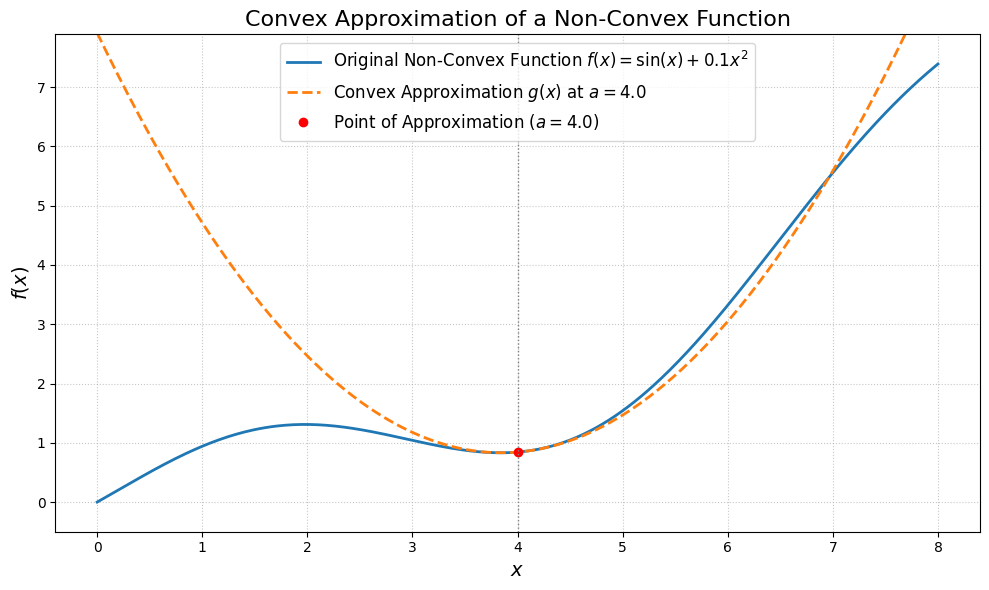

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Define the original non-convex function
def f(x):
    return np.sin(x) + 0.1 * x**2

# Define the first derivative
def f_prime(x):
    return np.cos(x) + 0.2 * x

# Define the second derivative
def f_double_prime(x):
    return -np.sin(x) + 0.2

# Set the point of approximation
a = 4.0

# Get values at point 'a'
f_a = f(a)
fp_a = f_prime(a)
fpp_a = f_double_prime(a)

# Define the second-order Taylor (quadratic) approximation
# This is a convex parabola because f_double_prime(a) is positive
def g(x):
    return f_a + fp_a * (x - a) + 0.5 * fpp_a * (x - a)**2

# Generate x values for plotting
x = np.linspace(0, 8, 400)
y_f = f(x)
y_g = g(x)

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(x, y_f, label='Original Non-Convex Function $f(x) = \\sin(x) + 0.1x^2$', linewidth=2)
plt.plot(x, y_g, label=f'Convex Approximation $g(x)$ at $a={a}$', linestyle='--', linewidth=2)

# Mark the point of approximation
plt.plot(a, f_a, 'ro', label=f'Point of Approximation ($a={a}$)')

# Add labels, title, legend, and grid
plt.title('Convex Approximation of a Non-Convex Function', fontsize=16)
plt.xlabel('$x$', fontsize=14)
plt.ylabel('$f(x)$', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)

# Set y-limits to better see the approximation
plt.ylim(min(y_f) - 0.5, max(y_f) + 0.5)

# Add a vertical line to show the approximation point
plt.axvline(x=a, color='gray', linestyle=':', linewidth=1)

plt.tight_layout()
# Save the plot
plt.show()

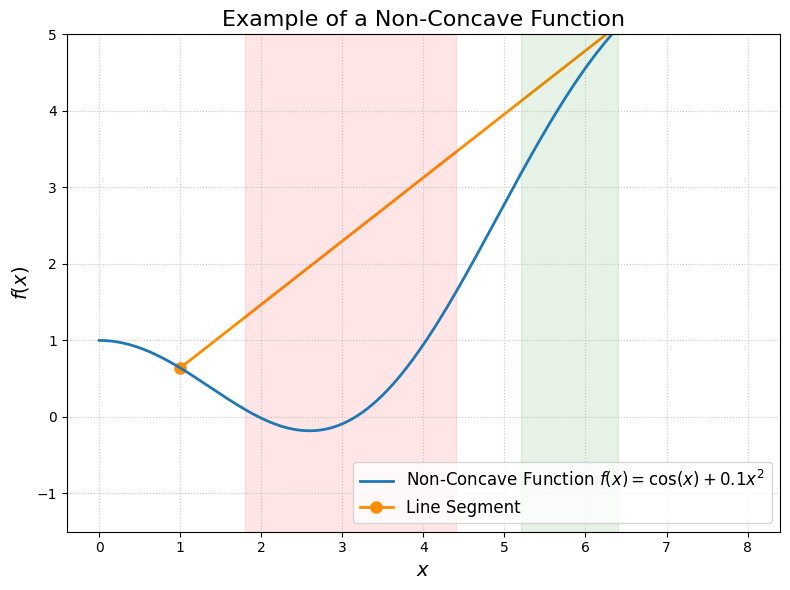

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# Define the original non-convex, non-concave function
def f(x):
    return np.cos(x) + 0.1 * x**2

# Generate x values for plotting
x = np.linspace(0, 8, 400)
y_f = f(x)

# Define the two points for the secant line
x1, x2 = 1.0, 6.5
y1, y2 = f(x1), f(x2)

# Create the plot
plt.figure(figsize=(8,6))
plt.plot(x, y_f, label='Non-Concave Function $f(x) = \\cos(x) + 0.1x^2$', linewidth=2, zorder=2)

# Plot the line segment (secant line)
plt.plot([x1, x2], [y1, y2], 'o-', label='Line Segment', color='darkorange', linewidth=2, markersize=8, zorder=1)

# Add labels, title, legend, and grid
plt.title('Example of a Non-Concave Function', fontsize=16)
plt.xlabel('$x$', fontsize=14)
plt.ylabel('$f(x)$', fontsize=14)
plt.legend(fontsize=12, loc='lower right')
plt.grid(True, linestyle=':', alpha=0.7)

# Highlight regions
plt.axvspan(1.8, 4.4, color='red', alpha=0.1, label='Line segment is ABOVE graph')
plt.axvspan(5.2, 6.4, color='green', alpha=0.1, label='Line segment is BELOW graph')

plt.ylim(-1.5, 5)
plt.tight_layout()

# Save the plot
plt.show()

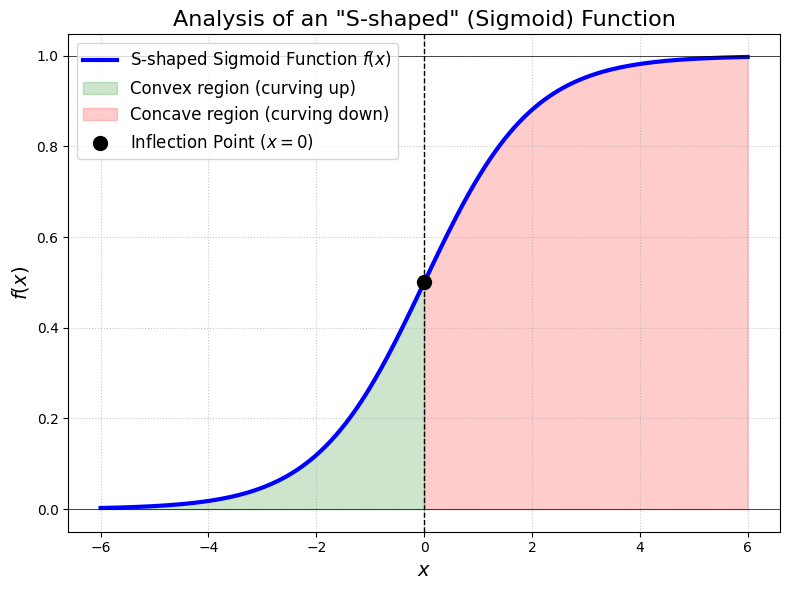

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Define the logistic (sigmoid) function
def f(x):
    return 1 / (1 + np.exp(-x))

# Generate x values for plotting
x = np.linspace(-6, 6, 400)
y_f = f(x)

# The inflection point is at x=0 for this function
inflection_point_x = 0
inflection_point_y = f(inflection_point_x)

# Create the plot
plt.figure(figsize=(8,6))
plt.plot(x, y_f, label='S-shaped Sigmoid Function $f(x)$', linewidth=3, color='blue')

# Highlight the convex part (x < 0)
x_convex = np.linspace(-6, 0, 200)
y_convex = f(x_convex)
plt.fill_between(x_convex, y_convex, 0, color='green', alpha=0.2, label='Convex region (curving up)')

# Highlight the concave part (x > 0)
x_concave = np.linspace(0, 6, 200)
y_concave = f(x_concave)
plt.fill_between(x_concave, y_concave, 0, color='red', alpha=0.2, label='Concave region (curving down)')

# Mark the inflection point
plt.plot(inflection_point_x, inflection_point_y, 'ko', markersize=10, label=f'Inflection Point ($x={inflection_point_x}$)')

# Add labels, title, legend, and grid
plt.title('Analysis of an "S-shaped" (Sigmoid) Function', fontsize=16)
plt.xlabel('$x$', fontsize=14)
plt.ylabel('$f(x)$', fontsize=14)
plt.legend(fontsize=12, loc='upper left')
plt.grid(True, linestyle=':', alpha=0.7)

plt.axhline(y=0, color='black', linewidth=0.5)
plt.axhline(y=1, color='black', linewidth=0.5)
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)

plt.tight_layout()
# Save the plot
plt.savefig('s_shape_function.png')

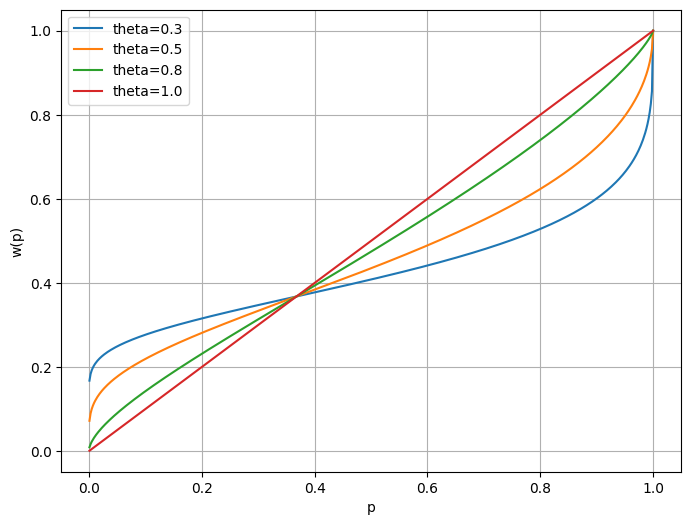

In [6]:
import numpy as np
import matplotlib.pyplot as plt

p = np.linspace(0.001, 1, 500)

def prelec_weight(p, alpha):
    return np.exp(-((-np.log(p)) ** alpha))

alphas = [0.3, 0.5, 0.8, 1.0]

plt.figure(figsize=(8,6))
for a in alphas:
    plt.plot(p, prelec_weight(p, a), label=f'theta={a}')

plt.xlabel("p")
plt.ylabel("w(p)")
plt.legend()
plt.grid(True)

plt.show()